In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Input, LayerNormalization
from tensorflow.keras.optimizers import Adam
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, KFold
from tensorflow.keras.utils import to_categorical
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import numpy as np
import tensorflow as tf
from sklearn.model_selection import KFold

In [2]:
# 📌 Load Data
df = pd.read_csv("../mci/pose_features_master.csv")

In [3]:
df.head()

,Patient_ID,Modality,Window_Start,Window_End,Label,Timestamp_Mean,Timestamp_Std,Left Shoulder_Mean,Left Shoulder_Std,Right Shoulder_Mean,...,Left Knee_Jerk_Mean,Right Knee_Velocity_Mean,Right Knee_Acceleration_Mean,Right Knee_Jerk_Mean,Left Ankle_Velocity_Mean,Left Ankle_Acceleration_Mean,Left Ankle_Jerk_Mean,Right Ankle_Velocity_Mean,Right Ankle_Acceleration_Mean,Right Ankle_Jerk_Mean
0,1,Pose,0,30,Healthy,0.483387,0.288547,-0.754012,6.783806,0.754012,...,339.460262,28.860714,282.794635,-339.460262,18.345920,-341.004093,-215.785063,-18.345920,341.004093,215.785063
1,1,Pose,15,45,Healthy,0.983443,0.288547,1.415687,7.215773,-1.415687,...,-637.349895,-54.187116,-137.193998,637.349895,22.356888,333.972008,-262.962139,-22.356888,-333.972008,262.962139
2,1,Pose,30,60,Healthy,1.483498,0.288547,-1.535920,7.318624,1.535920,...,691.479560,58.789189,-60.877667,-691.479560,-54.509111,-199.209446,641.137201,54.509111,199.209446,-641.137201
3,1,Pose,45,75,Healthy,1.983554,0.288547,1.068728,6.959626,-1.068728,...,-481.146900,-40.906829,235.666143,481.146900,65.813854,-11.742487,-774.103808,-65.813854,11.742487,774.103808
4,1,Pose,60,90,Healthy,2.483609,0.288547,-0.192791,6.616778,0.192791,...,86.795456,7.379299,-320.322069,-86.795456,-51.947521,218.203405,611.007733,51.947521,-218.203405,-611.007733


In [5]:
def plot_history(history, title):
    fig, axs = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

    # Accuracy Plot (Top)
    axs[0].plot(history.history['accuracy'], label="Train Accuracy")
    axs[0].plot(history.history['val_accuracy'], label="Validation Accuracy")
    axs[0].set_title(f"Model Accuracy - {title}")
    axs[0].set_ylabel("Accuracy")
    axs[0].legend(loc="lower right")

    # Loss Plot (Bottom)
    axs[1].plot(history.history['loss'], label="Train Loss")
    axs[1].plot(history.history['val_loss'], label="Validation Loss")
    axs[1].set_title(f"Model Loss - {title}")
    axs[1].set_xlabel("Epochs")
    axs[1].set_ylabel("Loss")
    axs[1].legend(loc="upper right")

    plt.tight_layout()
    plt.show()


In [6]:
X = df.drop(columns=["Label","Patient_ID","Modality","Window_Start","Window_End","Timestamp_Mean","Timestamp_Std",'Timestamp_Velocity_Mean', 'Timestamp_Acceleration_Mean',
       'Timestamp_Jerk_Mean'])
y = df["Label"].map({"Healthy": 0, "MCI": 1})


In [7]:
X.head()

,Left Shoulder_Mean,Left Shoulder_Std,Right Shoulder_Mean,Right Shoulder_Std,Left Elbow_Mean,Left Elbow_Std,Right Elbow_Mean,Right Elbow_Std,Left Wrist_Mean,Left Wrist_Std,...,Left Knee_Jerk_Mean,Right Knee_Velocity_Mean,Right Knee_Acceleration_Mean,Right Knee_Jerk_Mean,Left Ankle_Velocity_Mean,Left Ankle_Acceleration_Mean,Left Ankle_Jerk_Mean,Right Ankle_Velocity_Mean,Right Ankle_Acceleration_Mean,Right Ankle_Jerk_Mean
0,-0.754012,6.783806,0.754012,6.783806,2.032756,9.546322,-2.032756,9.546322,2.007161,10.729716,...,339.460262,28.860714,282.794635,-339.460262,18.345920,-341.004093,-215.785063,-18.345920,341.004093,215.785063
1,1.415687,7.215773,-1.415687,7.215773,-1.668591,9.244159,1.668591,9.244159,-2.337592,11.007914,...,-637.349895,-54.187116,-137.193998,637.349895,22.356888,333.972008,-262.962139,-22.356888,-333.972008,262.962139
2,-1.535920,7.318624,1.535920,7.318624,0.666260,8.694620,-0.666260,8.694620,1.773991,10.555236,...,691.479560,58.789189,-60.877667,-691.479560,-54.509111,-199.209446,641.137201,54.509111,199.209446,-641.137201
3,1.068728,6.959626,-1.068728,6.959626,0.590889,8.671637,-0.590889,8.671637,-0.531911,9.967369,...,-481.146900,-40.906829,235.666143,481.146900,65.813854,-11.742487,-774.103808,-65.813854,11.742487,774.103808
4,-0.192791,6.616778,0.192791,6.616778,-1.622047,9.209197,1.622047,9.209197,-0.913603,10.083281,...,86.795456,7.379299,-320.322069,-86.795456,-51.947521,218.203405,611.007733,51.947521,-218.203405,-611.007733


In [8]:
from sklearn.decomposition import PCA
from sklearn.kernel_approximation import RBFSampler
from sklearn.preprocessing import StandardScaler
import pandas as pd

# 🔹 Step 1: Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ================== PCA Variant ==================
# 🔹 Step 2: Apply PCA to reduce to 4 components
pca = PCA(n_components=4)
X_pca = pca.fit_transform(X_scaled)

# 🔹 Step 3: Create PCA DataFrame
pca_feature_names = [f"PCA_Component_{i+1}" for i in range(X_pca.shape[1])]
df_pca = pd.DataFrame(X_pca, columns=pca_feature_names)
df_pca["Label"] = y

# ================== RFF Variant ==================
# 🔹 Step 4: Apply Random Fourier Features (RBF kernel approx)
rff = RBFSampler(gamma=0.1, n_components=16, random_state=42)  # You can tune n_components
X_rff = rff.fit_transform(X_scaled)

# 🔹 Step 5: Create RFF DataFrame
rff_feature_names = [f"RFF_Feature_{i+1}" for i in range(X_rff.shape[1])]
df_rff = pd.DataFrame(X_rff, columns=rff_feature_names)
df_rff["Label"] = y

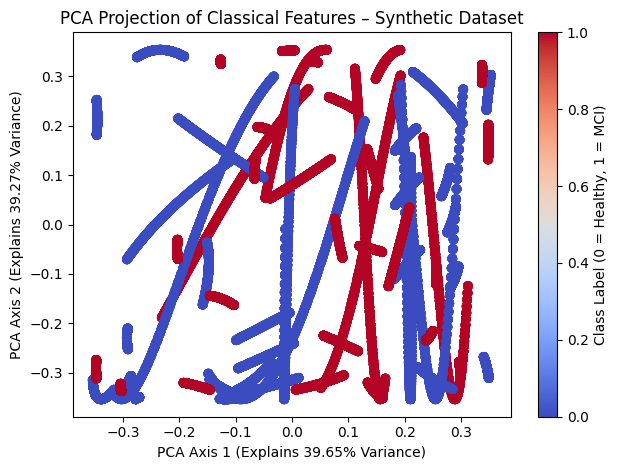

In [9]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import seaborn as sns

plt.scatter(X_rff[:, 0], X_rff[:, 1], c=y, cmap="coolwarm")
plt.xlabel("PCA Axis 1 (Explains {:.2f}% Variance)".format(pca.explained_variance_ratio_[0] * 100))
plt.ylabel("PCA Axis 2 (Explains {:.2f}% Variance)".format(pca.explained_variance_ratio_[1] * 100))
plt.title("PCA Projection of Classical Features – Synthetic Dataset")
plt.colorbar(label="Class Label (0 = Healthy, 1 = MCI)")
plt.tight_layout()
plt.show()

In [10]:
from sklearn.kernel_approximation import RBFSampler

# Step 1: Full RFF transformation using best params
rff = RBFSampler(gamma=0.1, n_components=16, random_state=42)  # You can tune n_components
X_rff_all = rff.fit_transform(X)

n_pca = 4

# Step 2: Train/val split (after RFF)
X_train_full, X_val_full, y_train, y_val = train_test_split(X_rff_all, y, test_size=0.2, random_state=42)

# Step 3: Apply PCA (cap to max dim if needed)
pca = PCA(n_components=4)
X_train_pca = pca.fit_transform(X_train_full)
X_val_pca = pca.transform(X_val_full)

# Step 4: Reshape for RNN
X_train_rnn = X_train_pca.reshape(-1, 1, n_pca)
X_val_rnn = X_val_pca.reshape(-1, 1, n_pca)

# Step 5: Define final model
model = tf.keras.Sequential([
    tf.keras.layers.LSTM(64, return_sequences=True, input_shape=(1, X_train_rnn.shape[2])),
    tf.keras.layers.LSTM(32),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

# Compile
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0002, clipvalue=0.5),
              loss="binary_crossentropy",
              metrics=["accuracy"])

# Train
history = model.fit(X_train_rnn, y_train, epochs=30, validation_data=(X_val_rnn, y_val), batch_size=32, verbose=1)

Epoch 1/30


c:\Users\basma\OneDrive\Documents\THESIS\QML\qe-feature-representation\.venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1797/1797 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.5099 - loss: 0.6928 - val_accuracy: 0.5182 - val_loss: 0.6924
Epoch 2/30
1797/1797 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.5238 - loss: 0.6913 - val_accuracy: 0.5120 - val_loss: 0.6915
Epoch 3/30
1797/1797 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.5286 - loss: 0.6902 - val_accuracy: 0.5206 - val_loss: 0.6909
Epoch 4/30
1797/1797 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.5301 - loss: 0.6897 - val_accuracy: 0.5218 - val_loss: 0.6907
Epoch 5/30
1797/1797 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.5278 - loss: 0.6894 - val_accuracy: 0.5236 - val_loss: 0.6902
Epoch 6/30
1797/1797 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.5300 - loss: 0.6892 - val_accuracy: 0.5220 - val_loss: 0.6910
Epoch 7/30
1797/1797 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.5295 - loss: 0.6891 - val_accuracy: 0.5257 - val_loss: 0.6899
Epoch 8/30
1797/1797 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.5296 - loss: 0.6888 - val_accurac

In [12]:
# ✅ Evaluate
test_loss, test_acc = model.evaluate(X_val_rnn, y_val)
print(f"DNN Test Accuracy: {test_acc:.4f} | Loss: {test_loss:.4f}")

450/450 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5358 - loss: 0.6875
DNN Test Accuracy: 0.5358 | Loss: 0.6875


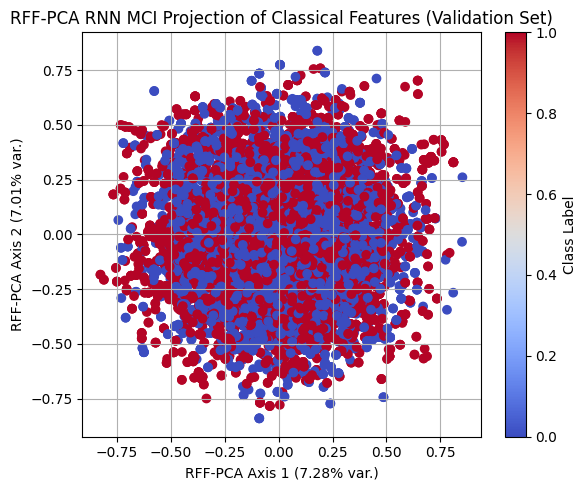

In [14]:
import matplotlib.pyplot as plt

# Project the validation data to 2D using a new PCA for visualization
pca_vis = PCA(n_components=2)
X_val_vis = pca_vis.fit_transform(X_val_full)

# Plot
plt.figure(figsize=(6, 5))
plt.scatter(X_val_vis[:, 0], X_val_vis[:, 1], c=y_val, cmap="coolwarm")
plt.xlabel(f"RFF-PCA Axis 1 ({pca_vis.explained_variance_ratio_[0]*100:.2f}% var.)")
plt.ylabel(f"RFF-PCA Axis 2 ({pca_vis.explained_variance_ratio_[1]*100:.2f}% var.)")
plt.title("RFF-PCA RNN MCI Projection of Classical Features (Validation Set)")
plt.colorbar(label="Class Label")
plt.grid(True)
plt.tight_layout()
plt.show()


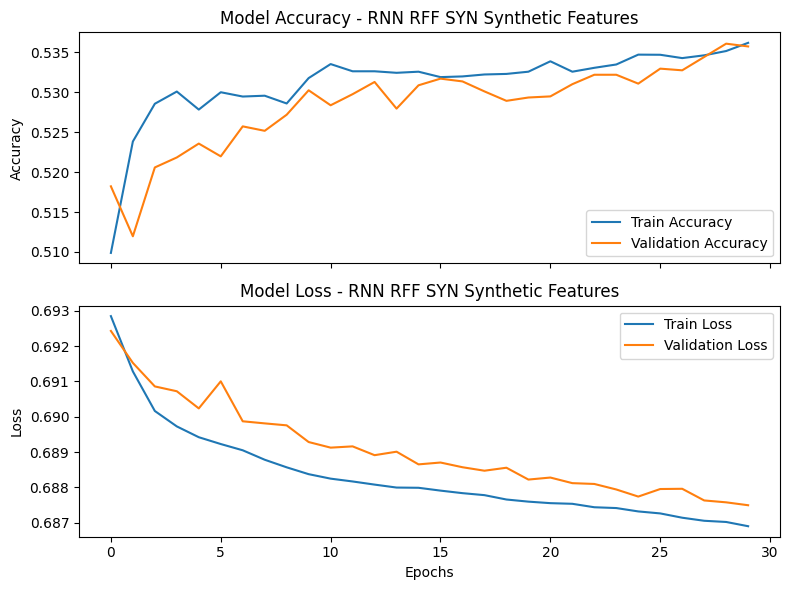

In [15]:
plot_history(history, "RNN RFF SYN Synthetic Features")

450/450 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


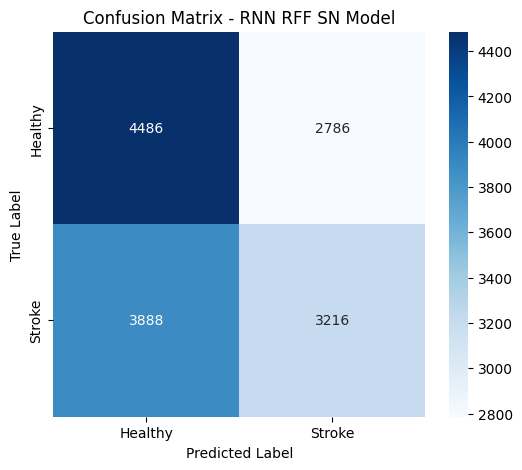

Classification Report:
               precision    recall  f1-score   support

           0       0.54      0.62      0.57      7272
           1       0.54      0.45      0.49      7104

    accuracy                           0.54     14376
   macro avg       0.54      0.53      0.53     14376
weighted avg       0.54      0.54      0.53     14376



In [16]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# Step 1: Get Model Predictions
y_pred_probs = model.predict(X_val_rnn)  # Get prediction probabilities


# Step 2: Adjust Decision Threshold
threshold = 0.5
y_pred = (y_pred_probs[:, 0] > threshold).astype(int)

# Step 3: Convert one-hot encoded labels (if needed)
if len(y_val.shape) > 1 and y_val.shape[1] > 1:  # Check safely
    y_test = np.argmax(y_val, axis=1)  # Converts one-hot labels back to single-class


# Step 4: Compute Confusion Matrix
cm = confusion_matrix(y_val, y_pred)

# Step 5: Visualize Confusion Matrix
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Healthy", "Stroke"], yticklabels=["Healthy", "Stroke"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title(f"Confusion Matrix - RNN RFF SN Model")
plt.show()

# 🔹 Step 6: Print Classification Report
print("Classification Report:\n", classification_report(y_val, y_pred))

# K-Fold

In [17]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold

# Define number of folds
k = 5  
kf = KFold(n_splits=k, shuffle=True, random_state=42)

# Store metrics
train_accuracies = []
val_accuracies = []
train_losses = []
val_losses = []

# Placeholder for epoch-wise averaging
all_train_acc = []
all_val_acc = []
all_train_loss = []
all_val_loss = []

for fold, (train_idx, val_idx) in enumerate(kf.split(X_train_full)):
    print(f"\nTraining Fold {fold+1}/{k}")

    y_train = y_train.reset_index(drop=True)

    # Split data
    X_train_fold, X_val_fold = X_train_full[train_idx], X_train_full[val_idx]
    y_train_fold, y_val_fold = y_train[train_idx], y_train[val_idx]

    # Sequential model (LSTM)
    model = tf.keras.Sequential([
        tf.keras.layers.LSTM(64, return_sequences=True, input_shape=(X_train_full.shape[1], 1)),
        tf.keras.layers.LSTM(32),
        tf.keras.layers.Dense(16, activation='relu'),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ])

    # Compile
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
                loss="binary_crossentropy",
                metrics=["accuracy"])

    # Train model
    history = model.fit(X_train_fold, y_train_fold, 
                        epochs=20, batch_size=32, 
                        validation_data=(X_val_fold, y_val_fold), 
                        verbose=1)

    # Store per-epoch results
    train_accuracies.append(history.history['accuracy'])
    val_accuracies.append(history.history['val_accuracy'])
    train_losses.append(history.history['loss'])
    val_losses.append(history.history['val_loss'])

    # Evaluate model
    _, accuracy = model.evaluate(X_val_fold, y_val_fold, verbose=0)
    print(f"Fold {fold+1} Accuracy: {accuracy:.4f}")


Training Fold 1/5
Epoch 1/20


c:\Users\basma\OneDrive\Documents\THESIS\QML\qe-feature-representation\.venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1438/1438 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.5066 - loss: 0.6930 - val_accuracy: 0.5078 - val_loss: 0.6930
Epoch 2/20
1438/1438 ━━━━━━━━━━━━━━━━━━━━ 14s 10ms/step - accuracy: 0.5176 - loss: 0.6924 - val_accuracy: 0.5110 - val_loss: 0.6928
Epoch 3/20
1438/1438 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.5198 - loss: 0.6920 - val_accuracy: 0.5197 - val_loss: 0.6918
Epoch 4/20
1438/1438 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.5229 - loss: 0.6916 - val_accuracy: 0.5193 - val_loss: 0.6915
Epoch 5/20
1438/1438 ━━━━━━━━━━━━━━━━━━━━ 23s 16ms/step - accuracy: 0.5254 - loss: 0.6910 - val_accuracy: 0.5213 - val_loss: 0.6911
Epoch 6/20
1438/1438 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.5262 - loss: 0.6908 - val_accuracy: 0.5272 - val_loss: 0.6907
Epoch 7/20
1438/1438 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.5271 - loss: 0.6908 - val_accuracy: 0.5192 - val_loss: 0.6912
Epoch 8/20
1438/1438 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.5267 - loss: 0.6907 - v

c:\Users\basma\OneDrive\Documents\THESIS\QML\qe-feature-representation\.venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1438/1438 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.5080 - loss: 0.6930 - val_accuracy: 0.5193 - val_loss: 0.6929
Epoch 2/20
1438/1438 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.5151 - loss: 0.6927 - val_accuracy: 0.5093 - val_loss: 0.6928
Epoch 3/20
1438/1438 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.5188 - loss: 0.6926 - val_accuracy: 0.5052 - val_loss: 0.6930
Epoch 4/20
1438/1438 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.5185 - loss: 0.6924 - val_accuracy: 0.5089 - val_loss: 0.6925
Epoch 5/20
1438/1438 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.5185 - loss: 0.6924 - val_accuracy: 0.5121 - val_loss: 0.6925
Epoch 6/20
1438/1438 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.5203 - loss: 0.6922 - val_accuracy: 0.5212 - val_loss: 0.6924
Epoch 7/20
1438/1438 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.5237 - loss: 0.6919 - val_accuracy: 0.5220 - val_loss: 0.6921
Epoch 8/20
1438/1438 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.5253 - loss: 0.6914 - val

...

1438/1438 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.5127 - loss: 0.6928 - val_accuracy: 0.5146 - val_loss: 0.6927
Epoch 2/20
1438/1438 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.5188 - loss: 0.6924 - val_accuracy: 0.5195 - val_loss: 0.6925
Epoch 3/20
1438/1438 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.5221 - loss: 0.6920 - val_accuracy: 0.5185 - val_loss: 0.6919
Epoch 4/20
1438/1438 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.5230 - loss: 0.6917 - val_accuracy: 0.5227 - val_loss: 0.6915
Epoch 5/20
1438/1438 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.5248 - loss: 0.6913 - val_accuracy: 0.5266 - val_loss: 0.6912
Epoch 6/20
1438/1438 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.5264 - loss: 0.6911 - val_accuracy: 0.5241 - val_loss: 0.6913
Epoch 7/20
1438/1438 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.5265 - loss: 0.6910 - val_accuracy: 0.5253 - val_loss: 0.6912
Epoch 8/20
1438/1438 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.5262 - loss: 0.6910 - val

c:\Users\basma\OneDrive\Documents\THESIS\QML\qe-feature-representation\.venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1438/1438 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.5062 - loss: 0.6930 - val_accuracy: 0.5065 - val_loss: 0.6927
Epoch 2/20
1438/1438 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.5155 - loss: 0.6926 - val_accuracy: 0.5077 - val_loss: 0.6929
Epoch 3/20
1438/1438 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.5206 - loss: 0.6920 - val_accuracy: 0.5193 - val_loss: 0.6921
Epoch 4/20
1438/1438 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.5229 - loss: 0.6916 - val_accuracy: 0.5221 - val_loss: 0.6921
Epoch 5/20
1438/1438 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.5229 - loss: 0.6914 - val_accuracy: 0.5200 - val_loss: 0.6920
Epoch 6/20
1438/1438 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.5244 - loss: 0.6913 - val_accuracy: 0.5127 - val_loss: 0.6922
Epoch 7/20
1438/1438 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.5258 - loss: 0.6911 - val_accuracy: 0.5186 - val_loss: 0.6921
Epoch 8/20
1438/1438 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.5257 - loss: 0.6910 - val

c:\Users\basma\OneDrive\Documents\THESIS\QML\qe-feature-representation\.venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1438/1438 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.5038 - loss: 0.6931 - val_accuracy: 0.5117 - val_loss: 0.6929
Epoch 2/20
1438/1438 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.5124 - loss: 0.6928 - val_accuracy: 0.5236 - val_loss: 0.6922
Epoch 3/20
1438/1438 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.5159 - loss: 0.6926 - val_accuracy: 0.5236 - val_loss: 0.6918
Epoch 4/20
1438/1438 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.5156 - loss: 0.6925 - val_accuracy: 0.5293 - val_loss: 0.6913
Epoch 5/20
1438/1438 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.5161 - loss: 0.6923 - val_accuracy: 0.5356 - val_loss: 0.6906
Epoch 6/20
1438/1438 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.5195 - loss: 0.6918 - val_accuracy: 0.5349 - val_loss: 0.6907
Epoch 7/20
1438/1438 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.5205 - loss: 0.6915 - val_accuracy: 0.5363 - val_loss: 0.6900
Epoch 8/20
1438/1438 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.5207 - loss: 0.6911 - val


Final K-Fold Accuracy: 0.5293


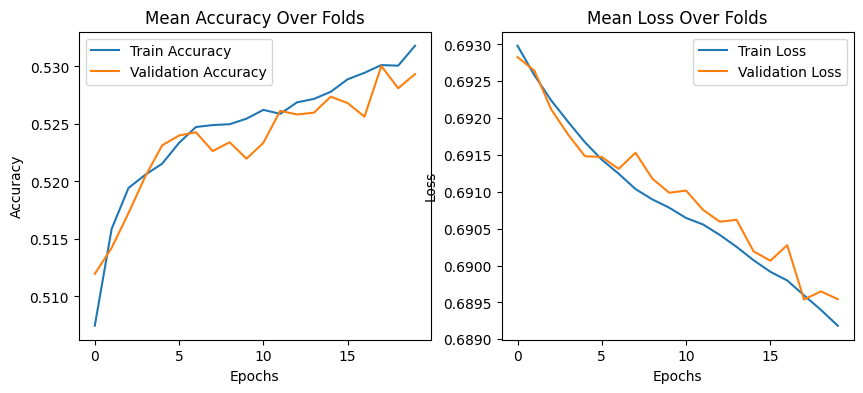

In [18]:
# Convert lists to NumPy arrays for easy averaging
train_accuracies = np.array(train_accuracies)
val_accuracies = np.array(val_accuracies)
train_losses = np.array(train_losses)
val_losses = np.array(val_losses)

# Compute mean accuracy/loss across folds
mean_train_acc = np.mean(train_accuracies, axis=0)
mean_val_acc = np.mean(val_accuracies, axis=0)
mean_train_loss = np.mean(train_losses, axis=0)
mean_val_loss = np.mean(val_losses, axis=0)

# 🎯 Final mean accuracy across folds
final_accuracy = np.mean(val_accuracies[:, -1])
print(f"\nFinal K-Fold Accuracy: {final_accuracy:.4f}")

# 📊 Plot Accuracy Curves
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(mean_train_acc, label='Train Accuracy')
plt.plot(mean_val_acc, label='Validation Accuracy')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Mean Accuracy Over Folds")
plt.legend()

# 📊 Plot Loss Curves
plt.subplot(1, 2, 2)
plt.plot(mean_train_loss, label='Train Loss')
plt.plot(mean_val_loss, label='Validation Loss')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Mean Loss Over Folds")
plt.legend()

plt.show()

In [20]:
import pandas as pd
import numpy as np

# Convert lists to numpy arrays
folds = list(range(1, len(train_accuracies) + 1))

# Create DataFrame with results per fold
df_results = pd.DataFrame({
    'Fold': folds,
    'Final Train Accuracy': [train_acc[-1] for train_acc in train_accuracies],
    'Final Validation Accuracy': [val_acc[-1] for val_acc in val_accuracies],
    'Final Train Loss': [train_loss[-1] for train_loss in train_losses],
    'Final Validation Loss': [val_loss[-1] for val_loss in val_losses]
})

# Print results
print("\n📊 K-Fold Cross-Validation Results:\n")
print(df_results)

# Compute summary statistics (mean & std deviation)
df_summary = df_results.describe().loc[['mean', 'std']]
print("\n📌 Summary Statistics (Mean & Std Deviation):\n")
print(df_summary)


📊 K-Fold Cross-Validation Results:

   Fold  Final Train Accuracy  Final Validation Accuracy  Final Train Loss  \
0     1              0.530400                   0.527954          0.689793   
1     2              0.536791                   0.532736          0.687949   
2     3              0.527379                   0.527172          0.690207   
3     4              0.528205                   0.522911          0.690489   
4     5              0.536236                   0.535913          0.687479   

   Final Validation Loss  
0               0.689827  
1               0.687796  
2               0.690817  
3               0.691872  
4               0.687410  

📌 Summary Statistics (Mean & Std Deviation):

          Fold  Final Train Accuracy  Final Validation Accuracy  \
mean  3.000000              0.531802                   0.529337   
std   1.581139              0.004445                   0.005067   

      Final Train Loss  Final Validation Loss  
mean          0.689183             